# Italy Price Model — Audi Q4 e-tron

Trains a regularisation-heavy price regression model on 227 Italian listings (snapshot, no lifecycle).  
Saves `saved_models/it_price_model_best.pkl` for use in `02_cross_market_arbitrage.ipynb`.

**Key constraints vs DE model:**
- `power_kw` / `power_hp` are corrupted (median 77 kW, impossible) → excluded; replaced by `power_kw_imputed` from model tier
- German text flags (has_matrix, has_ahk, has_pano, has_hud, has_acc, has_camera) all <1% in IT → excluded
- `door_count` / `seat_count` constant (all = 5) → excluded
- n=227 → stronger regularisation and 50 Optuna trials instead of 100

In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy.stats as stats
import shap
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

IT_PATH     = Path("../Italy/Preprocessing/outputs/audi_q4_it_snapshot_clean.parquet")
SAVE_DIR    = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

USE_LOG_TARGET = True
RANDOM_STATE   = 42
N_FOLDS        = 5
N_OPTUNA       = 50

MODEL_POWER_MAP = {"35": 125, "40": 150, "45": 195, "50": 220, "55": 250}

print(f"IT data path: {IT_PATH}")
print(f"Save directory: {SAVE_DIR}")

IT data path: ../Italy/Preprocessing/outputs/audi_q4_it_snapshot_clean.parquet
Save directory: saved_models


## 1 — Feature Selection for Italy

In [2]:
# ── Numeric features (exclude power_kw/hp corrupted; door/seat constant; battery_charging near-all-null) ──
NUMERIC_FEATURES = [
    "mileage_km",
    "vehicle_age_months",
    "electric_range_km",
    "wltp_consumption_kwh_100km",
    "previous_owner_count",
    "seller_rating_stars",
    "seller_rating_count",
    "image_count",
    "warranty_months",
    "mileage_per_month",
    "power_kw_imputed",
]

# ── Categorical ordinal ────────────────────────────────────────────────────────
CATEGORICAL_ORDINAL   = ["model_number_v2"]
MODEL_NUMBER_ORDER    = [["35", "40", "45", "50", "55"]]

# ── Categorical nominal (OHE) ─────────────────────────────────────────────────
CATEGORICAL_NOMINAL   = [
    "variant",
    "seller_type",
    "body_type",
    "exterior_color",
    "interior_color",
    "upholstery_material",
]

# ── Binary features ────────────────────────────────────────────────────────────
# Excluded: available_now_clean (all=1), had_accident_clean (all=0),
#           has_matrix/ahk/pano/hud/acc/camera (<1%), has_city_range/charging_time/battery_info (near-zero)
BINARY_FEATURES = [
    "is_sportback",
    "is_quattro",
    "is_s_line",
    "is_conditional_price_clean",
    "has_full_service_history_clean",
    "warranty_exists_clean",
    "seller_has_rating",
    "has_warranty_months",
    "duplicate_listing_id",
]

IT_FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_ORDINAL + CATEGORICAL_NOMINAL + BINARY_FEATURES

print(f"Total IT features: {len(IT_FEATURE_COLS)}")
print(f"  Numeric ({len(NUMERIC_FEATURES)}):          {NUMERIC_FEATURES}")
print(f"  Categorical ordinal ({len(CATEGORICAL_ORDINAL)}): {CATEGORICAL_ORDINAL}")
print(f"  Categorical nominal ({len(CATEGORICAL_NOMINAL)}):  {CATEGORICAL_NOMINAL}")
print(f"  Binary ({len(BINARY_FEATURES)}):              {BINARY_FEATURES}")

Total IT features: 27
  Numeric (11):          ['mileage_km', 'vehicle_age_months', 'electric_range_km', 'wltp_consumption_kwh_100km', 'previous_owner_count', 'seller_rating_stars', 'seller_rating_count', 'image_count', 'warranty_months', 'mileage_per_month', 'power_kw_imputed']
  Categorical ordinal (1): ['model_number_v2']
  Categorical nominal (6):  ['variant', 'seller_type', 'body_type', 'exterior_color', 'interior_color', 'upholstery_material']
  Binary (9):              ['is_sportback', 'is_quattro', 'is_s_line', 'is_conditional_price_clean', 'has_full_service_history_clean', 'warranty_exists_clean', 'seller_has_rating', 'has_warranty_months', 'duplicate_listing_id']


## 2 — Load & Prepare Data

In [3]:
df_raw = pd.read_parquet(IT_PATH)
print(f"Raw shape: {df_raw.shape}")

# Add imputed power from model tier
df_raw["power_kw_imputed"] = df_raw["model_number_v2"].map(MODEL_POWER_MAP).astype(float)

# Convert boolean columns to numeric to avoid dtype issues
for col in BINARY_FEATURES:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.lower()
                                    .map({'true': 1, 'false': 0, '1': 1, '0': 0,
                                          '1.0': 1, '0.0': 0, 'nan': np.nan}),
                                    errors='coerce')

# Drop rows with missing target
df_clean = df_raw.dropna(subset=["price_eur"]).copy()
print(f"After dropping null price: {len(df_clean)} rows")

y_raw = df_clean["price_eur"].astype(float).values
y     = np.log1p(y_raw) if USE_LOG_TARGET else y_raw

# Build feature matrix — fill missing categorical with 'missing'
for col in CATEGORICAL_ORDINAL + CATEGORICAL_NOMINAL:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).replace('nan', 'missing').replace('None', 'missing')

X = df_clean[IT_FEATURE_COLS].copy()
print(f"Feature matrix shape: {X.shape}")
print(f"Target: {'log(price_eur+1)' if USE_LOG_TARGET else 'price_eur'}")
print(f"Target range: €{y_raw.min():,.0f} – €{y_raw.max():,.0f}  (median €{np.median(y_raw):,.0f})")

Raw shape: (227, 94)
After dropping null price: 227 rows
Feature matrix shape: (227, 27)
Target: log(price_eur+1)
Target range: €22,500 – €73,776  (median €41,500)


## 3 — Brief EDA

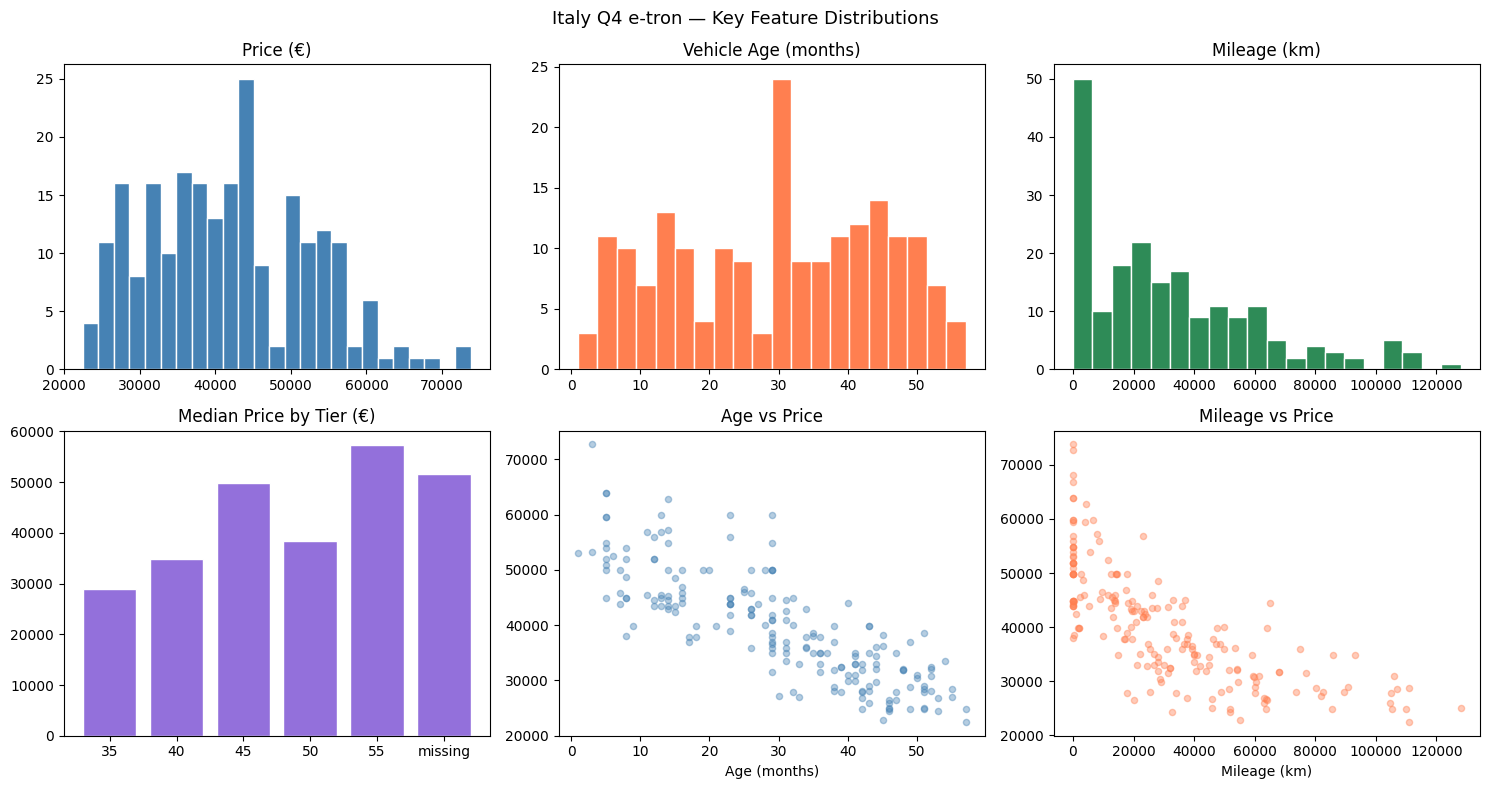

Missing values in feature matrix:
electric_range_km                 63.4
wltp_consumption_kwh_100km        54.6
warranty_months                   51.1
previous_owner_count              44.1
mileage_per_month                 15.4
vehicle_age_months                15.4
seller_rating_stars               15.0
seller_rating_count               15.0
mileage_km                        13.2
power_kw_imputed                   4.8
has_full_service_history_clean     3.5


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Italy Q4 e-tron — Key Feature Distributions", fontsize=13)

axes[0,0].hist(y_raw, bins=25, color='steelblue', edgecolor='white')
axes[0,0].set_title("Price (€)")

axes[0,1].hist(df_clean['vehicle_age_months'].dropna(), bins=20, color='coral', edgecolor='white')
axes[0,1].set_title("Vehicle Age (months)")

axes[0,2].hist(df_clean['mileage_km'].dropna(), bins=20, color='seagreen', edgecolor='white')
axes[0,2].set_title("Mileage (km)")

tier_prices = df_clean.groupby('model_number_v2')['price_eur'].median().sort_index()
axes[1,0].bar(tier_prices.index, tier_prices.values, color='mediumpurple', edgecolor='white')
axes[1,0].set_title("Median Price by Tier (€)")

axes[1,1].scatter(df_clean['vehicle_age_months'], df_clean['price_eur'],
                  alpha=0.4, color='steelblue', s=20)
axes[1,1].set_title("Age vs Price")
axes[1,1].set_xlabel("Age (months)")

axes[1,2].scatter(df_clean['mileage_km'], df_clean['price_eur'],
                  alpha=0.4, color='coral', s=20)
axes[1,2].set_title("Mileage vs Price")
axes[1,2].set_xlabel("Mileage (km)")

plt.tight_layout()
plt.show()

# Null summary for model features
null_pct = (X.isnull().mean() * 100).sort_values(ascending=False)
print("Missing values in feature matrix:")
print(null_pct[null_pct > 0].round(1).to_string())

## 4 — Preprocessing Pipeline

In [5]:
from sklearn.base import clone

numeric_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
])

cat_ordinal_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
    ('enc', OrdinalEncoder(
        categories=MODEL_NUMBER_ORDER,
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

cat_ohe_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
    ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

binary_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value=0)),
])

preprocessor = ColumnTransformer([
    ('num',     numeric_pipe,      NUMERIC_FEATURES),
    ('cat_ord', cat_ordinal_pipe,  CATEGORICAL_ORDINAL),
    ('cat_ohe', cat_ohe_pipe,      CATEGORICAL_NOMINAL),
    ('bin',     binary_pipe,       BINARY_FEATURES),
], remainder='drop')


def make_pipeline(estimator):
    """Return a fresh Pipeline with an independent clone of the preprocessor."""
    return Pipeline([('pre', clone(preprocessor)), ('model', clone(estimator))])


print("Preprocessor defined — using make_pipeline() everywhere to avoid shared-state bugs.")

Preprocessor defined — using make_pipeline() everywhere to avoid shared-state bugs.


## 5 — Model Comparison (5-fold CV)

In [6]:
def mape_score(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(name, estimator, X, y, y_raw, cv):
    fold_results = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        pipe = make_pipeline(estimator)
        pipe.fit(X_tr, y_tr)
        pred_log = pipe.predict(X_val)
        pred_eur = np.expm1(pred_log) if USE_LOG_TARGET else pred_log
        true_eur = y_raw[val_idx]
        fold_results.append({
            'rmse': np.sqrt(mean_squared_error(true_eur, pred_eur)),
            'mae':  mean_absolute_error(true_eur, pred_eur),
            'mape': mape_score(true_eur, pred_eur),
            'r2':   r2_score(true_eur, pred_eur),
        })
    fdf = pd.DataFrame(fold_results)
    return {
        'model': name,
        'rmse_mean': fdf['rmse'].mean(), 'rmse_std': fdf['rmse'].std(),
        'mae_mean':  fdf['mae'].mean(),  'mae_std':  fdf['mae'].std(),
        'mape_mean': fdf['mape'].mean(), 'mape_std': fdf['mape'].std(),
        'r2_mean':   fdf['r2'].mean(),   'r2_std':   fdf['r2'].std(),
    }


kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

BASELINE_MODELS = {
    "Ridge":         Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8,
                                            min_samples_leaf=5, random_state=RANDOM_STATE),
    "XGBoost":       XGBRegressor(n_estimators=300, max_depth=4, min_child_weight=5,
                                   learning_rate=0.05, subsample=0.8,
                                   random_state=RANDOM_STATE, verbosity=0),
    "LightGBM":      LGBMRegressor(n_estimators=300, max_depth=4, num_leaves=15,
                                    min_child_samples=20, learning_rate=0.05,
                                    subsample=0.8, random_state=RANDOM_STATE, verbose=-1),
}

print(f"Running {N_FOLDS}-fold CV for {len(BASELINE_MODELS)} models...")
cv_results = []
for name, est in BASELINE_MODELS.items():
    print(f"  {name}...", end=' ')
    res = evaluate_model(name, est, X, y, y_raw, kf)
    cv_results.append(res)
    print(f"RMSE €{res['rmse_mean']:,.0f} ± {res['rmse_std']:,.0f}   R² {res['r2_mean']:.3f}")

cv_df = pd.DataFrame(cv_results).sort_values('rmse_mean')
cv_df.index = range(1, len(cv_df)+1)

display_df = cv_df[['model','rmse_mean','rmse_std','mae_mean','mape_mean','r2_mean']].copy()
display_df.columns = ['Model','RMSE','RMSE±','MAE','MAPE%','R²']
display_df['RMSE'] = display_df['RMSE'].map('€{:,.0f}'.format)
display_df['RMSE±'] = display_df['RMSE±'].map('±€{:,.0f}'.format)
display_df['MAE']  = display_df['MAE'].map('€{:,.0f}'.format)
display_df['MAPE%'] = display_df['MAPE%'].map('{:.1f}%'.format)
display_df['R²']   = display_df['R²'].map('{:.3f}'.format)
print("\n=== 5-fold CV Comparison ===")
print(display_df.to_string(index=True))

Running 5-fold CV for 4 models...
  Ridge... RMSE €4,978 ± 829   R² 0.780
  Random Forest... 

RMSE €5,000 ± 662   R² 0.777
  XGBoost... 

RMSE €4,227 ± 455   R² 0.838
  LightGBM... 

RMSE €4,526 ± 408   R² 0.814

=== 5-fold CV Comparison ===
           Model    RMSE  RMSE±     MAE MAPE%     R²
1        XGBoost  €4,227  ±€455  €3,205  8.0%  0.838
2       LightGBM  €4,526  ±€408  €3,436  8.6%  0.814
3          Ridge  €4,978  ±€829  €3,699  8.9%  0.780
4  Random Forest  €5,000  ±€662  €3,886  9.5%  0.777


## 6 — Optuna Tuning (top 2 models, 50 trials each)

Tuning top 2 models: ['XGBoost', 'LightGBM']

Optuna [XGBoost]: 50 trials...


  Best RMSE: €4,432   params: {'n_estimators': 773, 'max_depth': 3, 'min_child_weight': 8, 'learning_rate': 0.026414761878177092, 'subsample': 0.8041867198391713, 'colsample_bytree': 0.9990848066519122, 'reg_alpha': 0.35741429837257727, 'reg_lambda': 0.02729287688656523, 'gamma': 0.0020018346665791036}

Optuna [LightGBM]: 50 trials...


  Best RMSE: €4,531   params: {'n_estimators': 207, 'num_leaves': 17, 'max_depth': 8, 'learning_rate': 0.10674535022553905, 'min_child_samples': 28, 'subsample': 0.9991988189007066, 'colsample_bytree': 0.9398838436150214, 'reg_alpha': 0.02729287688656523, 'reg_lambda': 2.6676135443796496}


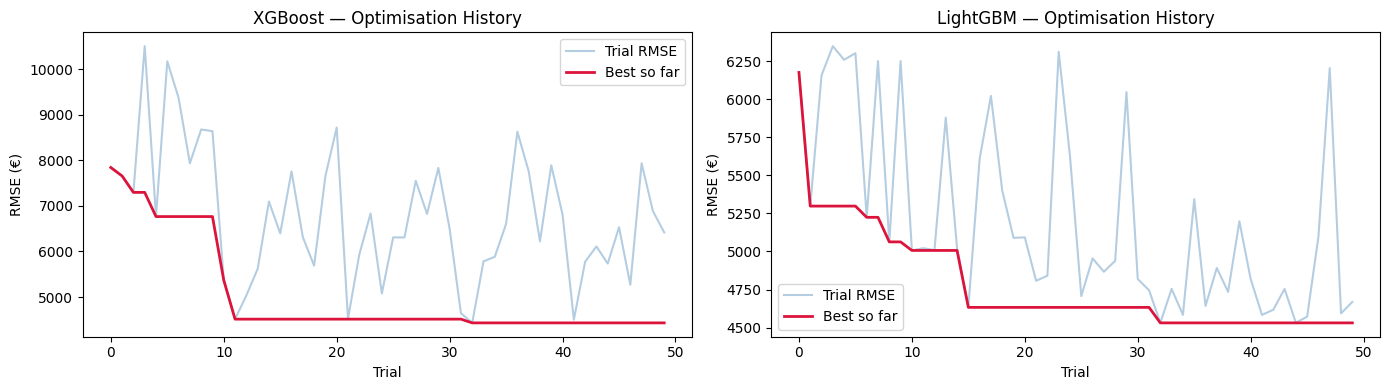

In [7]:
top2_names = cv_df['model'].values[:2].tolist()
print(f"Tuning top 2 models: {top2_names}")


def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'num_leaves':        trial.suggest_int('num_leaves', 10, 63),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': RANDOM_STATE, 'verbose': -1,
    }
    rmses = []
    for tr, val in kf.split(X):
        pipe = make_pipeline(LGBMRegressor(**params))
        pipe.fit(X.iloc[tr], y[tr])
        pred_eur = np.expm1(pipe.predict(X.iloc[val])) if USE_LOG_TARGET else pipe.predict(X.iloc[val])
        rmses.append(np.sqrt(mean_squared_error(y_raw[val], pred_eur)))
    return np.mean(rmses)


def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 15),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.0, 5.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 3.0),
        'random_state': RANDOM_STATE, 'verbosity': 0,
    }
    rmses = []
    for tr, val in kf.split(X):
        pipe = make_pipeline(XGBRegressor(**params))
        pipe.fit(X.iloc[tr], y[tr])
        pred_eur = np.expm1(pipe.predict(X.iloc[val])) if USE_LOG_TARGET else pipe.predict(X.iloc[val])
        rmses.append(np.sqrt(mean_squared_error(y_raw[val], pred_eur)))
    return np.mean(rmses)


def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 4, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 15),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.6, 0.8]),
        'random_state': RANDOM_STATE,
    }
    rmses = []
    for tr, val in kf.split(X):
        pipe = make_pipeline(RandomForestRegressor(**params))
        pipe.fit(X.iloc[tr], y[tr])
        pred_eur = np.expm1(pipe.predict(X.iloc[val])) if USE_LOG_TARGET else pipe.predict(X.iloc[val])
        rmses.append(np.sqrt(mean_squared_error(y_raw[val], pred_eur)))
    return np.mean(rmses)


def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.1, 100.0, log=True)
    rmses = []
    for tr, val in kf.split(X):
        pipe = make_pipeline(Ridge(alpha=alpha))
        pipe.fit(X.iloc[tr], y[tr])
        pred_eur = np.expm1(pipe.predict(X.iloc[val])) if USE_LOG_TARGET else pipe.predict(X.iloc[val])
        rmses.append(np.sqrt(mean_squared_error(y_raw[val], pred_eur)))
    return np.mean(rmses)


OBJECTIVE_MAP = {
    'LightGBM':      objective_lgbm,
    'XGBoost':       objective_xgb,
    'Random Forest': objective_rf,
    'Ridge':         objective_ridge,
}

tuned_results = {}
studies = {}

for model_name in top2_names:
    print(f"\nOptuna [{model_name}]: {N_OPTUNA} trials...")
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(OBJECTIVE_MAP[model_name], n_trials=N_OPTUNA, show_progress_bar=False)
    tuned_results[model_name] = study.best_value
    studies[model_name] = study
    print(f"  Best RMSE: €{study.best_value:,.0f}   params: {study.best_params}")

# Plot optimisation history
fig, axes = plt.subplots(1, len(top2_names), figsize=(14, 4))
if len(top2_names) == 1:
    axes = [axes]
for ax, name in zip(axes, top2_names):
    vals = [t.value for t in studies[name].trials if t.value is not None]
    running_min = pd.Series(vals).cummin()
    ax.plot(vals, alpha=0.4, color='steelblue', label='Trial RMSE')
    ax.plot(running_min, color='crimson', lw=2, label='Best so far')
    ax.set_title(f"{name} — Optimisation History")
    ax.set_xlabel("Trial")
    ax.set_ylabel("RMSE (€)")
    ax.legend()
plt.tight_layout()
plt.show()

## 7 — Select Best Model & Refit on Full Data

In [8]:
best_name = min(tuned_results, key=tuned_results.get)
best_rmse = tuned_results[best_name]
second_name = [n for n in top2_names if n != best_name][0]
print(f"Best model: {best_name}  RMSE €{best_rmse:,.0f}")
print(f"Runner-up:  {second_name}  RMSE €{tuned_results[second_name]:,.0f}")

best_params = studies[best_name].best_params

if best_name == 'LightGBM':
    best_est = LGBMRegressor(**best_params, random_state=RANDOM_STATE, verbose=-1)
elif best_name == 'XGBoost':
    best_est = XGBRegressor(**best_params, random_state=RANDOM_STATE, verbosity=0)
elif best_name == 'Random Forest':
    best_est = RandomForestRegressor(**best_params, random_state=RANDOM_STATE)
else:
    best_est = Ridge(**best_params)

# make_pipeline gives a fresh independent preprocessor — no shared-state issues
best_pipeline = make_pipeline(best_est)
best_pipeline.fit(X, y)
print(f"Full-data refit complete. Preprocessor fitted on {len(X)} rows.")

Best model: XGBoost  RMSE €4,432
Runner-up:  LightGBM  RMSE €4,531


Full-data refit complete. Preprocessor fitted on 227 rows.


## 8 — Model Diagnostics

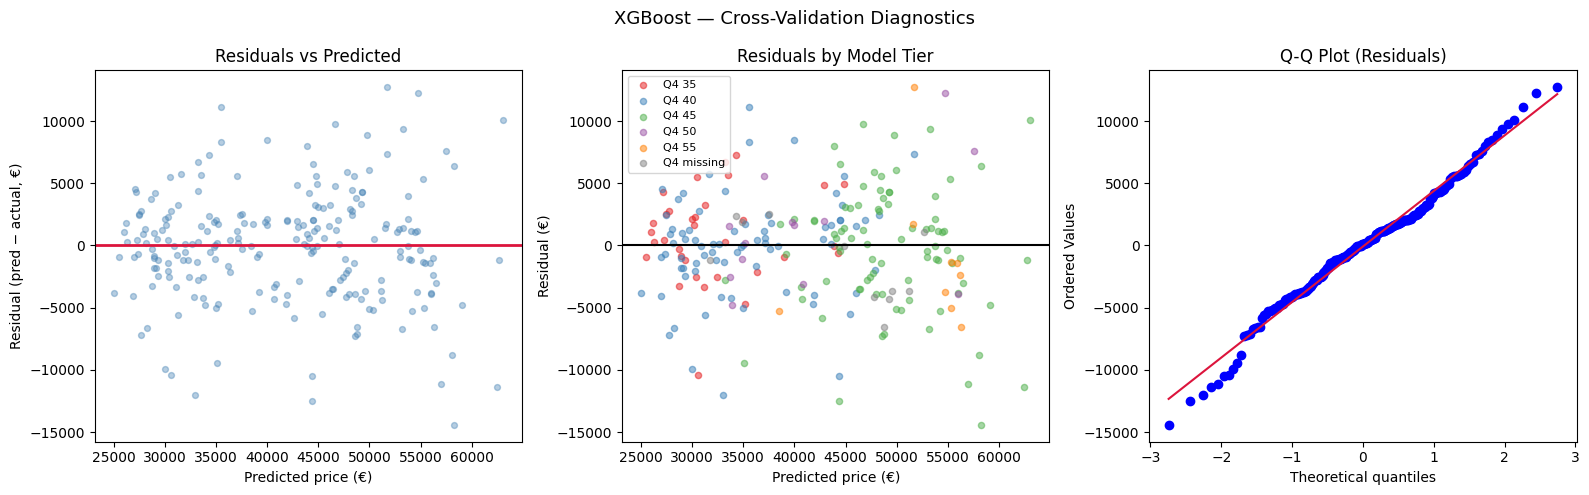

CV RMSE:  €4,457
CV MAE:   €3,351
CV MAPE:  8.2%
CV R²:    0.827
Residual σ: €4,456  (±1σ prediction band)


In [9]:
# Cross-val predictions for diagnostics — each fold gets its OWN pipeline clone
pred_cv_log = np.empty_like(y)
for tr, val in kf.split(X):
    pipe = make_pipeline(best_est)
    pipe.fit(X.iloc[tr], y[tr])
    pred_cv_log[val] = pipe.predict(X.iloc[val])

pred_cv_eur = np.expm1(pred_cv_log) if USE_LOG_TARGET else pred_cv_log
residuals = pred_cv_eur - y_raw

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"{best_name} — Cross-Validation Diagnostics", fontsize=13)

axes[0].scatter(pred_cv_eur, residuals, alpha=0.4, s=18, color='steelblue')
axes[0].axhline(0, color='crimson', lw=2)
axes[0].set_xlabel("Predicted price (€)")
axes[0].set_ylabel("Residual (pred − actual, €)")
axes[0].set_title("Residuals vs Predicted")

tier_col = df_clean['model_number_v2'].fillna('unknown')
tiers_present = sorted(tier_col.unique())
colors_map = {'35':'#e41a1c','40':'#377eb8','45':'#4daf4a','50':'#984ea3','55':'#ff7f00','unknown':'gray'}
for tier in tiers_present:
    mask = tier_col == tier
    axes[1].scatter(pred_cv_eur[mask], residuals[mask],
                    alpha=0.5, s=20, label=f'Q4 {tier}', color=colors_map.get(tier, 'gray'))
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_xlabel("Predicted price (€)")
axes[1].set_ylabel("Residual (€)")
axes[1].set_title("Residuals by Model Tier")
axes[1].legend(fontsize=8)

import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title("Q-Q Plot (Residuals)")
axes[2].get_lines()[1].set_color('crimson')

plt.tight_layout()
plt.show()

print(f"CV RMSE:  €{np.sqrt(mean_squared_error(y_raw, pred_cv_eur)):,.0f}")
print(f"CV MAE:   €{mean_absolute_error(y_raw, pred_cv_eur):,.0f}")
print(f"CV MAPE:  {mape_score(y_raw, pred_cv_eur):.1f}%")
print(f"CV R²:    {r2_score(y_raw, pred_cv_eur):.3f}")
print(f"Residual σ: €{residuals.std():,.0f}  (±1σ prediction band)")

## 9 — SHAP Feature Importance

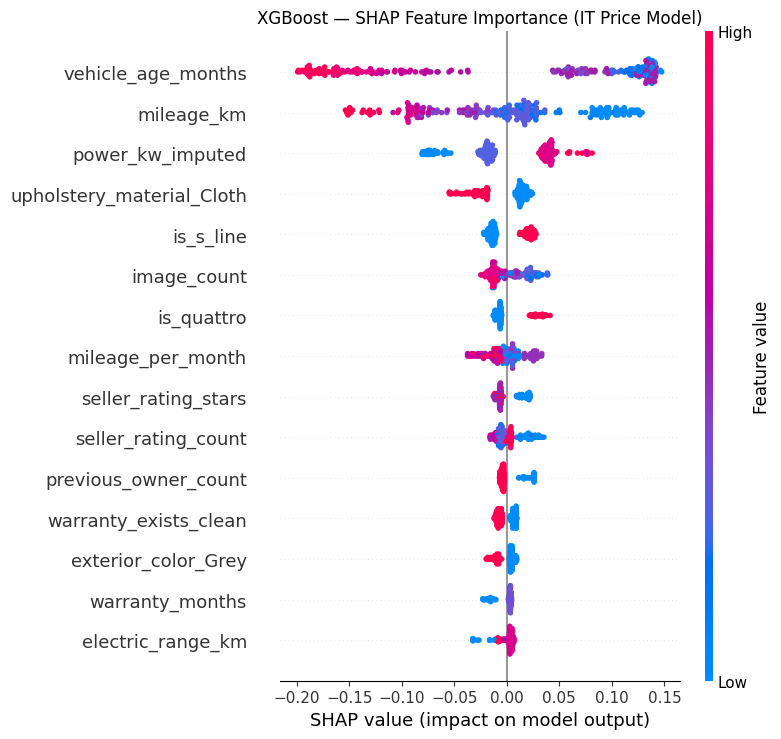

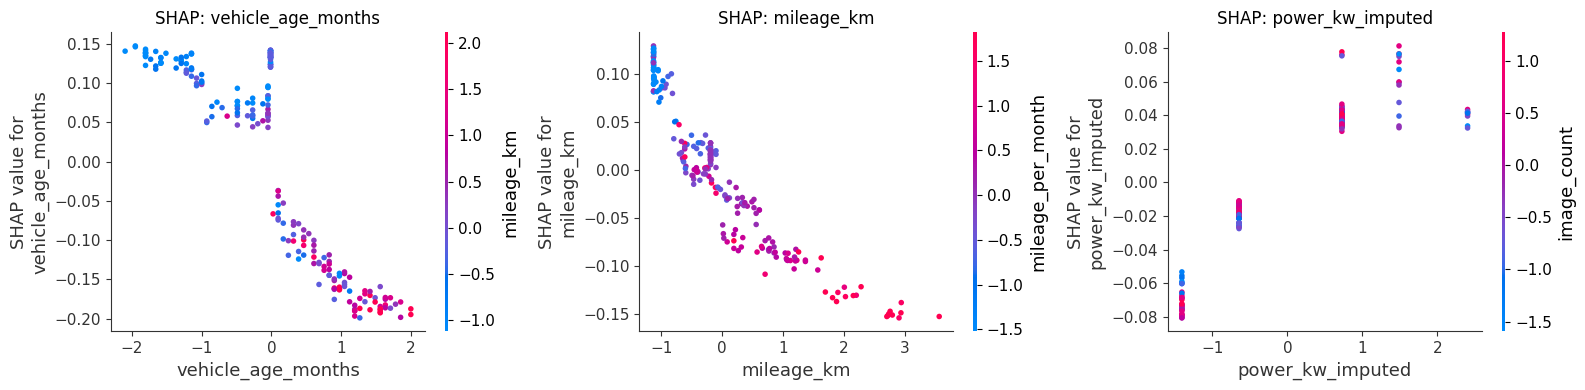

In [10]:
# Transform X with the fitted preprocessor for SHAP
X_transformed = best_pipeline.named_steps['pre'].transform(X)

# Get feature names after transformation
num_names  = NUMERIC_FEATURES
ord_names  = CATEGORICAL_ORDINAL
ohe_names  = list(best_pipeline.named_steps['pre']
                  .named_transformers_['cat_ohe']
                  .named_steps['enc']
                  .get_feature_names_out(CATEGORICAL_NOMINAL))
bin_names  = BINARY_FEATURES
all_feat_names = num_names + ord_names + ohe_names + bin_names

model_fitted = best_pipeline.named_steps['model']


def plot_feature_importances_fallback(model, feat_names, title):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_)
    else:
        print("No feature importances available.")
        return
    top_idx = np.argsort(imp)[-15:]
    plt.figure(figsize=(9, 6))
    plt.barh([feat_names[i] for i in top_idx], imp[top_idx], color='steelblue')
    plt.xlabel('Feature Importance')
    plt.title(title)
    plt.tight_layout()
    plt.show()


shap_values = None
try:
    if best_name in ('LightGBM', 'XGBoost', 'Random Forest'):
        if best_name == 'XGBoost':
            # Use tree_path_dependent to avoid XGBoost internal shape check bug
            explainer = shap.TreeExplainer(model_fitted,
                                           feature_perturbation='tree_path_dependent')
        else:
            explainer = shap.TreeExplainer(model_fitted)
        shap_values = explainer.shap_values(X_transformed)
    else:
        explainer = shap.LinearExplainer(model_fitted, X_transformed)
        shap_values = explainer.shap_values(X_transformed)
except Exception as shap_err:
    print(f"SHAP TreeExplainer failed: {shap_err}")
    print("Falling back to model feature importances.")
    plot_feature_importances_fallback(model_fitted, all_feat_names,
                                      f"{best_name} — Feature Importances (IT Price Model)")

if shap_values is not None:
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_transformed,
        feature_names=all_feat_names,
        max_display=15,
        show=False,
    )
    plt.title(f"{best_name} — SHAP Feature Importance (IT Price Model)")
    plt.tight_layout()
    plt.show()

    if best_name != 'Ridge':
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        for ax, feat in zip(axes, ['vehicle_age_months', 'mileage_km', 'power_kw_imputed']):
            if feat in all_feat_names:
                fi = all_feat_names.index(feat)
                try:
                    shap.dependence_plot(fi, shap_values, X_transformed,
                                         feature_names=all_feat_names, ax=ax, show=False)
                    ax.set_title(f"SHAP: {feat}")
                except Exception:
                    ax.set_title(f"{feat} (unavailable)")
        plt.tight_layout()
        plt.show()

## 10 — Save Model & Metadata

In [11]:
model_path = SAVE_DIR / "it_price_model_best.pkl"
meta_path  = SAVE_DIR / "it_price_model_meta.json"

joblib.dump(best_pipeline, model_path)

meta = {
    "feature_cols":           IT_FEATURE_COLS,
    "numeric_features":       NUMERIC_FEATURES,
    "categorical_ordinal":    CATEGORICAL_ORDINAL,
    "categorical_nominal":    CATEGORICAL_NOMINAL,
    "binary_features":        BINARY_FEATURES,
    "target":                 "price_eur",
    "use_log_target":         USE_LOG_TARGET,
    "best_model_name":        best_name,
    "second_model_name":      second_name,
    "tuned_rmse_best":        best_rmse,
    "tuned_rmse_second":      tuned_results[second_name],
    "n_training_rows":        len(df_clean),
    "model_number_order":     MODEL_NUMBER_ORDER[0],
    "power_kw_imputed_map":   MODEL_POWER_MAP,
    "excluded_features_reason": {
        "power_kw":            "corrupted_parsing_in_italy_scrape_median_77kw",
        "power_hp":            "corrupted_parsing_in_italy_scrape",
        "door_count":          "constant_5_in_all_it_listings",
        "seat_count":          "constant_5_in_all_it_listings",
        "battery_charging_time_min": "97pct_missing_in_it",
        "has_matrix":          "german_abbreviation_0pct_in_it_titles",
        "has_ahk":             "german_abbreviation_0pct_in_it_titles",
        "has_pano":            "0pct_in_it_listings",
        "has_hud":             "0pct_in_it_listings",
        "has_acc":             "0.9pct_near_zero_variance",
        "has_camera":          "1.3pct_near_zero_variance",
        "available_now_clean": "constant_1_in_all_it_listings",
        "had_accident_clean":  "constant_0_in_all_it_listings",
        "has_city_range":      "constant_0_no_city_range_data_in_it",
        "has_charging_time":   "1.3pct_near_zero_variance",
        "has_battery_info":    "2.2pct_near_zero_variance",
    },
    "trained_at": datetime.now().isoformat(),
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Model saved: {model_path}")
print(f"Meta  saved: {meta_path}")
print(f"\n{'='*50}")
print(f"IT Price Model Summary")
print(f"{'='*50}")
print(f"Best model:        {best_name}")
print(f"CV RMSE (tuned):   €{best_rmse:,.0f}")
print(f"Training rows:     {len(df_clean)}")
print(f"Features:          {len(IT_FEATURE_COLS)}")
print(f"Log target:        {USE_LOG_TARGET}")

Model saved: saved_models/it_price_model_best.pkl
Meta  saved: saved_models/it_price_model_meta.json

IT Price Model Summary
Best model:        XGBoost
CV RMSE (tuned):   €4,432
Training rows:     227
Features:          27
Log target:        True
